# 04 - TF-IDF + Logistic Regression

Modelo linear sobre representacao esparsa. Rapido, artefato pequeno e com probabilidades calibraveis - o perfil que melhor casa com o requisito de latencia.

**Entrada:** `data/processed/{train,val,test}.parquet`
**Saidas:** `models/tfidf_logreg/model.pkl`, `metrics.json`, `search_log.csv`

> Este notebook tem a **mesma estrutura** dos demais notebooks de modelo. So muda o
> estimador. Isso e proposital: mantem a comparacao justa e o codigo previsivel.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import ensure_dirs, load_config, set_seed

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

SEED = set_seed()
CONFIG = load_config()
ensure_dirs()
print(f"seed={SEED} | classes={CONFIG['classes']}")

seed=42 | classes=['normal', 'atencao', 'urgente']


## 1. Busca de hiperparametros

A selecao acontece na **validacao**. O split de teste nao e tocado aqui.

In [2]:
from src.models.pipelines import param_grid

CANDIDATO = "tfidf_logreg"
grade = param_grid(CANDIDATO)
print(f"Combinacoes a avaliar: {len(grade)}")
for params in grade:
    print(" ", params)

Combinacoes a avaliar: 3
  {'C': 0.5, 'class_weight': 'balanced', 'max_iter': 1000}
  {'C': 1.0, 'class_weight': 'balanced', 'max_iter': 1000}
  {'C': 3.0, 'class_weight': 'balanced', 'max_iter': 1000}


## 2. Treino, avaliacao e latencia

`run_candidate` executa a busca, treina o modelo final, avalia em validacao e teste, mede latencia pelo protocolo unico e persiste os artefatos.

In [3]:
from src.models.experiment import run_candidate

resultado = run_candidate(CANDIDATO)
print("Melhores parametros:", resultado["best_params"])

Melhores parametros: {'C': 3.0, 'class_weight': 'balanced', 'max_iter': 1000}


### Log da busca

In [4]:
display(resultado["search_log"].head(10))

,params,f1_macro,f1_weighted,accuracy,recall_normal,precision_normal,recall_atencao,precision_atencao,recall_urgente,precision_urgente
0,"{""C"": 3.0, ""class_weight"": ""balanced"", ""max_it...",0.751344,0.746827,0.747031,0.712644,0.726208,0.762602,0.762602,0.785523,0.759067
1,"{""C"": 0.5, ""class_weight"": ""balanced"", ""max_it...",0.750249,0.745794,0.746437,0.692529,0.732523,0.777236,0.763578,0.796247,0.742500
2,"{""C"": 1.0, ""class_weight"": ""balanced"", ""max_it...",0.749767,0.744166,0.744656,0.699713,0.727952,0.760976,0.757282,0.801609,0.753149


## 3. Metricas

In [5]:
comparativo = pd.DataFrame({
    "validacao": resultado["val_metrics"],
    "teste": resultado["test_metrics"],
}).round(4)
display(comparativo)

,validacao,teste
f1_macro,0.7513,0.7489
f1_weighted,0.7468,0.7456
accuracy,0.7470,0.7460
recall_normal,0.7126,0.7044
precision_normal,0.7262,0.7372
recall_atencao,0.7626,0.7630
precision_atencao,0.7626,0.7655
recall_urgente,0.7855,0.7957
precision_urgente,0.7591,0.7309


> Uma queda grande de validacao para teste indica overfitting na busca de hiperparametros.

In [6]:
from src.data.loader import load_split
from src.evaluation.metrics import confusion, report

teste = load_split("test")
print(report(teste["urgencia"], resultado["test_pred"]))

              precision    recall  f1-score   support

      normal       0.74      0.70      0.72       697
     atencao       0.77      0.76      0.76       616
     urgente       0.73      0.80      0.76       372

    accuracy                           0.75      1685
   macro avg       0.74      0.75      0.75      1685
weighted avg       0.75      0.75      0.75      1685



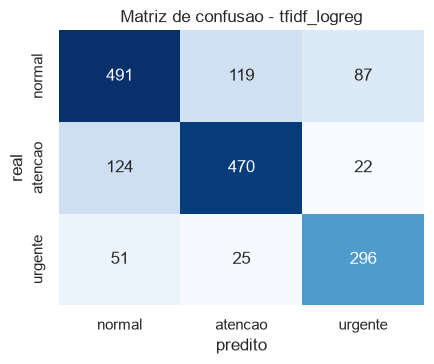

'urgente' classificado como 'normal': 51 de 372


In [7]:
matriz = confusion(teste["urgencia"], resultado["test_pred"])
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_title(f"Matriz de confusao - {CANDIDATO}")
plt.tight_layout()
plt.show()

erro_critico = matriz.loc["urgente", "normal"]
total_urgente = matriz.loc["urgente"].sum()
print(f"'urgente' classificado como 'normal': {erro_critico} de {total_urgente}")

> `urgente` predito como `normal` e o erro clinicamente caro. Um modelo com F1-macro alto e essa celula alta nao serve.

## 4. Latencia

In [8]:
latencia = pd.Series(resultado["latency"]).round(3).to_frame("ms")
display(latencia)

teto = CONFIG["promotion"]["max_latency_p95_ms"]
p95 = resultado["latency"]["latency_p95_ms"]
print(f"p95={p95:.2f}ms | teto={teto}ms | {'DENTRO' if p95 <= teto else 'ACIMA'}")

,ms
latency_p50_ms,2.010
latency_p95_ms,3.217
latency_p99_ms,3.931
latency_mean_ms,2.076
latency_n_calls,1000.000


p95=3.22ms | teto=15.0ms | DENTRO


---

## Notas

_Preencher: o modelo superou o baseline? Onde concentra o erro? O p95 esta dentro do teto?_